# 4.2 — Sobol sobre o surrogate SVR k*=6

Calcula índices de Sobol (S_i e S_Ti) para os 6 inputs de S_6 = {T1, RRC1, BRC1, RRC2, BRC2, RFF},
usando o surrogate SVR reduzido (k*=6) treinado na Etapa 3.
Gera tabela consolidada (18 linhas) e gráfico comparativo 8 vs. 6 inputs.

## Seção 1 — Imports e configuração

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import joblib
from SALib.sample import saltelli
from SALib.analyze import sobol
import pathlib
import importlib.metadata

print(f"numpy     : {np.__version__}")
print(f"pandas    : {pd.__version__}")
print(f"joblib    : {joblib.__version__}")
print(f"matplotlib: {matplotlib.__version__}")

try:
    salib_version = importlib.metadata.version("SALib")
except Exception:
    salib_version = "desconhecida"
print(f"SALib     : {salib_version}")

numpy     : 2.3.3
pandas    : 2.3.3
joblib    : 1.5.3
matplotlib: 3.10.7
SALib     : 1.5.2


In [ ]:
# Caminhos base
BASE      = pathlib.Path("../../..")   # raiz do projeto a partir de ARTEFATOS/ETAPA_4/4.2/
DIR_E3    = BASE / "ARTEFATOS" / "ETAPA_3"
DIR_41    = BASE / "ARTEFATOS" / "ETAPA_4" / "4.1"    # resultados Sobol 8-inputs (leitura)
DIR_E4    = BASE / "ARTEFATOS" / "ETAPA_4" / "4.2"    # saídas desta sub-etapa
DIR_SCAL  = BASE / "ARTEFATOS" / "ETAPA_0" / "processed"

# Constante de amostragem
N = 2048

# Índices das 6 features no vetor completo de 8
# Ordem 8-inputs: [P1, T1, T2, RRC1, BRC1, RRC2, BRC2, RFF]
# S_6 = {T1, RRC1, BRC1, RRC2, BRC2, RFF} → índices 1,3,4,5,6,7
S6_IDX = [1, 3, 4, 5, 6, 7]

# Problema de 6 inputs (domínio físico)
problem_6 = {
    "num_vars": 6,
    "names":   ["T1", "RRC1", "BRC1", "RRC2", "BRC2", "RFF"],
    "bounds":  [[200, 300], [1, 10], [0.5, 10], [1, 10], [0.5, 10], [0.01, 0.25]],
}

print("problem_6:", problem_6)
print("N =", N)
print(f"Avaliações por output: {N * (6 + 2):,}")

## Seção 2 — Carga dos modelos e scalers

In [3]:
# Modelos SVR reduzido k*=6
model_ET  = joblib.load(DIR_E3 / "reduzido" / "SVR" / "ET"      / "k6" / "model.pkl")
model_M   = joblib.load(DIR_E3 / "reduzido" / "SVR" / "M_CH3OH" / "k6" / "model.pkl")
model_x   = joblib.load(DIR_E3 / "reduzido" / "SVR" / "x_CH3OH" / "k6" / "model.pkl")

print("Modelos carregados:")
print(" ET     :", type(model_ET))
print(" M_CH3OH:", type(model_M))
print(" x_CH3OH:", type(model_x))

Modelos carregados:
 ET     : <class 'sklearn.svm._classes.SVR'>
 M_CH3OH: <class 'sklearn.svm._classes.SVR'>
 x_CH3OH: <class 'sklearn.svm._classes.SVR'>


In [4]:
# Scalers do espaço de entrada (8 features)
scaler_X_min   = np.load(DIR_SCAL / "scaler_X_min.npy")    # shape (8,)
scaler_X_scale = np.load(DIR_SCAL / "scaler_X_scale.npy")  # shape (8,)

# Extrair apenas as colunas de S_6
scaler_min_6   = scaler_X_min[S6_IDX]    # shape (6,)
scaler_scale_6 = scaler_X_scale[S6_IDX]  # shape (6,)

print("scaler_X_min   (completo):", scaler_X_min)
print("scaler_X_scale (completo):", scaler_X_scale)
print()
print("scaler_min_6   (S6):", scaler_min_6)
print("scaler_scale_6 (S6):", scaler_scale_6)

# Teste de predict com vetor zero normalizado (6 features)
zero_6 = np.zeros((1, 6))
print()
print("Teste predict zero_6:")
print(" ET     :", model_ET.predict(zero_6))
print(" M_CH3OH:", model_M.predict(zero_6))
print(" x_CH3OH:", model_x.predict(zero_6))

scaler_X_min   (completo): [5.00277030e+01 2.00119416e+02 8.50023229e+01 1.00675628e+00
 5.02164445e-01 1.00059745e+00 5.01838760e-01 1.00071268e-02]
scaler_X_scale (completo): [49.96782685 99.84375386  9.99290816  8.9864509   9.49155418  8.99763685
  9.49631006  0.23988401]

scaler_min_6   (S6): [2.00119416e+02 1.00675628e+00 5.02164445e-01 1.00059745e+00
 5.01838760e-01 1.00071268e-02]
scaler_scale_6 (S6): [99.84375386  8.9864509   9.49155418  8.99763685  9.49631006  0.23988401]

Teste predict zero_6:
 ET     : [0.28345361]
 M_CH3OH: [0.46796567]
 x_CH3OH: [0.83944304]


## Seção 3 — Geração das amostras de Saltelli

In [5]:
# Amostragem Saltelli no espaço físico (6 inputs)
# Nota: parâmetro seed não disponível na versão instalada do SALib — omitido.
# A sequência quasi-aleatória de Sobol é determinística por construção.
param_values_6 = saltelli.sample(problem_6, N, calc_second_order=False)

print("Shape param_values_6:", param_values_6.shape)
print(f"Esperado: ({N * (6 + 2)}, 6) = ({N*(6+2)}, 6)")
assert param_values_6.shape == (N * (6 + 2), 6), "Shape inesperado!"
print("OK")

Shape param_values_6: (16384, 6)
Esperado: (16384, 6) = (16384, 6)
OK


In [6]:
# Normalizar com as colunas de scaler correspondentes a S_6
# Transformação: X_norm = (X - min) / scale
param_values_6_norm = (param_values_6 - scaler_min_6) / scaler_scale_6

print("Estatísticas pós-normalização (esperado ~[0, 1]):")
print(f"  min : {param_values_6_norm.min(axis=0).round(4)}")
print(f"  max : {param_values_6_norm.max(axis=0).round(4)}")

Estatísticas pós-normalização (esperado ~[0, 1]):
  min : [-0.001  -0.0005  0.      0.0002  0.0001  0.0002]
  max : [1.0001 1.0005 1.0004 1.     1.     1.0002]


## Seção 4 — Cálculo dos índices de Sobol por output

In [7]:
outputs_info = [
    ("ET",      model_ET),
    ("M_CH3OH", model_M),
    ("x_CH3OH", model_x),
]

dfs = []

for output_name, model in outputs_info:
    # Predição do surrogate sobre as amostras normalizadas
    Y = model.predict(param_values_6_norm)
    assert Y.shape == (N * (6 + 2),), f"Shape Y inesperado: {Y.shape}"

    # Análise de Sobol
    # Nota: seed omitido (não disponível na versão instalada)
    Si = sobol.analyze(problem_6, Y, calc_second_order=False, conf_level=0.95)

    df = pd.DataFrame({
        "output":  output_name,
        "feature": problem_6["names"],
        "S1":      Si["S1"],
        "S1_conf": Si["S1_conf"],
        "ST":      Si["ST"],
        "ST_conf": Si["ST_conf"],
    })
    dfs.append(df)
    print(f"[{output_name}] Y min={Y.min():.4f}  max={Y.max():.4f}  S1 sum={Si['S1'].sum():.4f}  ST sum={Si['ST'].sum():.4f}")

df_4_2 = pd.concat(dfs, ignore_index=True)
print(f"\ndf_4_2 shape: {df_4_2.shape}  (esperado: 18 × 6)")

[ET] Y min=-0.0190  max=0.9844  S1 sum=0.8530  ST sum=1.1581
[M_CH3OH] Y min=-0.0190  max=1.0372  S1 sum=0.8628  ST sum=1.1267
[x_CH3OH] Y min=-0.1347  max=1.1037  S1 sum=0.7097  ST sum=1.3763

df_4_2 shape: (18, 6)  (esperado: 18 × 6)


## Seção 5 — Tabela consolidada e validação

In [8]:
# Reordenar colunas
df_4_2 = df_4_2[["output", "feature", "S1", "S1_conf", "ST", "ST_conf"]]

# Validações
assert df_4_2.shape[0] == 18,          f"Esperadas 18 linhas, obtidas {df_4_2.shape[0]}"
assert df_4_2.isna().sum().sum() == 0, "NaN detectado na tabela"

violations_st_s1 = (df_4_2["ST"] < df_4_2["S1"] - 1e-6).sum()
if violations_st_s1 > 0:
    print(f"AVISO: {violations_st_s1} pares com ST < S1 (ruído de estimativa — esperado pequeno)")
else:
    print("OK: ST >= S1 em todos os 18 pares")

for out in ["ET", "M_CH3OH", "x_CH3OH"]:
    s1_sum = df_4_2.loc[df_4_2["output"] == out, "S1"].sum()
    assert s1_sum <= 1.05, f"[{out}] Soma S1 = {s1_sum:.4f} > 1 (fora do esperado)"
    print(f"[{out}] Soma S1 = {s1_sum:.4f}  (≤ 1 ✓)")

print()
print(df_4_2.to_string(index=False))

OK: ST >= S1 em todos os 18 pares
[ET] Soma S1 = 0.8530  (≤ 1 ✓)
[M_CH3OH] Soma S1 = 0.8628  (≤ 1 ✓)
[x_CH3OH] Soma S1 = 0.7097  (≤ 1 ✓)

 output feature        S1  S1_conf       ST  ST_conf
     ET      T1  0.006780 0.018267 0.094557 0.009962
     ET    RRC1 -0.006956 0.008506 0.026079 0.003206
     ET    BRC1  0.327166 0.030918 0.392419 0.030538
     ET    RRC2  0.090008 0.022215 0.126033 0.013501
     ET    BRC2  0.008038 0.007559 0.013626 0.002034
     ET     RFF  0.427942 0.044186 0.505418 0.042152
M_CH3OH      T1  0.192759 0.030755 0.231827 0.021648
M_CH3OH    RRC1  0.167482 0.030445 0.240712 0.019860
M_CH3OH    BRC1  0.208204 0.029997 0.272396 0.024760
M_CH3OH    RRC2  0.041406 0.013666 0.067299 0.007530
M_CH3OH    BRC2  0.055658 0.018307 0.082158 0.009201
M_CH3OH     RFF  0.197290 0.033400 0.232293 0.016736
x_CH3OH      T1  0.006451 0.011299 0.027702 0.003911
x_CH3OH    RRC1  0.507671 0.056069 0.767764 0.061240
x_CH3OH    BRC1  0.112377 0.037606 0.343660 0.045382
x_CH3OH    RRC

In [9]:
# Salvar CSV
csv_path = DIR_E4 / "4.2_sobol_6inputs_resultados.csv"
df_4_2.to_csv(csv_path, index=False)
print(f"Salvo: {csv_path}")

Salvo: ../ETAPA_4/4.2_sobol_6inputs_resultados.csv


## Seção 6 — Gráfico comparativo 8 vs. 6 inputs

In [ ]:
# Carregar resultados de 4.1 (surrogate 8-input)
df_4_1 = pd.read_csv(DIR_41 / "4.1_sobol_8inputs_resultados.csv")

# Filtrar apenas as 6 features comuns
features_6 = problem_6["names"]
df_4_1_6 = df_4_1[df_4_1["feature"].isin(features_6)].copy()

print("4.1 (features S6):")
print(df_4_1_6[["output", "feature", "ST"]].to_string(index=False))

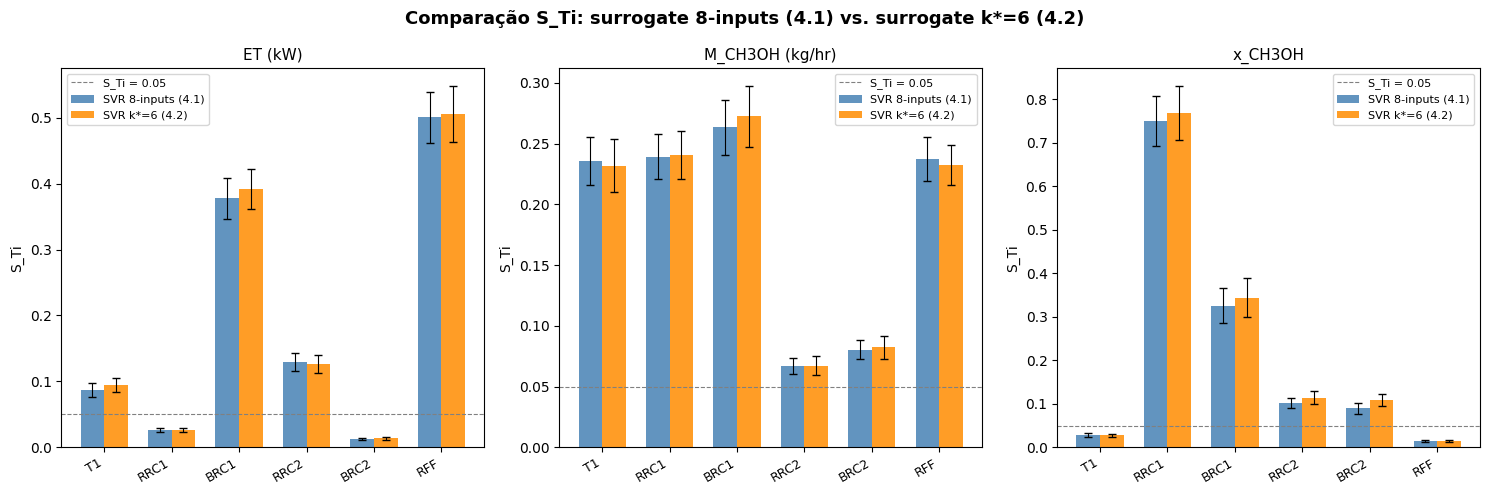

Salvo: ../ETAPA_4/4.2_sobol_comparacao_8vs6_por_output.png


In [11]:
outputs_list  = ["ET", "M_CH3OH", "x_CH3OH"]
output_labels = {"ET": "ET (kW)", "M_CH3OH": "M_CH3OH (kg/hr)", "x_CH3OH": "x_CH3OH"}

fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=False)
fig.suptitle("Comparação S_Ti: surrogate 8-inputs (4.1) vs. surrogate k*=6 (4.2)",
             fontsize=13, fontweight="bold")

bar_width = 0.35
x = np.arange(len(features_6))

for ax, out in zip(axes, outputs_list):
    st_8 = (
        df_4_1_6[df_4_1_6["output"] == out]
        .set_index("feature")["ST"]
        .reindex(features_6)
        .values
    )
    st_8_conf = (
        df_4_1_6[df_4_1_6["output"] == out]
        .set_index("feature")["ST_conf"]
        .reindex(features_6)
        .values
    )

    st_6 = (
        df_4_2[df_4_2["output"] == out]
        .set_index("feature")["ST"]
        .reindex(features_6)
        .values
    )
    st_6_conf = (
        df_4_2[df_4_2["output"] == out]
        .set_index("feature")["ST_conf"]
        .reindex(features_6)
        .values
    )

    ax.bar(x - bar_width/2, st_8, bar_width,
           label="SVR 8-inputs (4.1)", color="steelblue", alpha=0.85,
           yerr=st_8_conf, capsize=3, error_kw={"linewidth": 0.8})
    ax.bar(x + bar_width/2, st_6, bar_width,
           label="SVR k*=6 (4.2)", color="darkorange", alpha=0.85,
           yerr=st_6_conf, capsize=3, error_kw={"linewidth": 0.8})

    ax.axhline(0.05, color="gray", linestyle="--", linewidth=0.8, label="S_Ti = 0.05")
    ax.set_xticks(x)
    ax.set_xticklabels(features_6, rotation=30, ha="right", fontsize=9)
    ax.set_ylabel("S_Ti", fontsize=10)
    ax.set_title(output_labels[out], fontsize=11)
    ax.legend(fontsize=8)
    ax.set_ylim(bottom=0)

plt.tight_layout()

png_path = DIR_E4 / "4.2_sobol_comparacao_8vs6_por_output.png"
plt.savefig(png_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Salvo: {png_path}")

## Validação final

In [12]:
csv_ok  = csv_path.exists()
png_ok  = png_path.exists()
rows_ok = df_4_2.shape[0] == 18
nan_ok  = df_4_2.isna().sum().sum() == 0
st_s1_ok = (df_4_2["ST"] >= df_4_2["S1"] - 1e-6).all()

print(f"CSV 18 linhas          : {'OK' if rows_ok  else 'FALHOU'}")
print(f"Sem NaN                : {'OK' if nan_ok   else 'FALHOU'}")
print(f"ST >= S1 (todos)       : {'OK' if st_s1_ok else 'AVISO'}")
print(f"CSV salvo              : {'OK' if csv_ok   else 'FALHOU'}")
print(f"PNG comparativo salvo  : {'OK' if png_ok   else 'FALHOU'}")

if all([rows_ok, nan_ok, csv_ok, png_ok]):
    print("\nEtapa 4.2 concluída com sucesso.")
else:
    print("\nEtapa 4.2 com pendências — revisar itens FALHOU acima.")

CSV 18 linhas          : OK
Sem NaN                : OK
ST >= S1 (todos)       : OK
CSV salvo              : OK
PNG comparativo salvo  : OK

Etapa 4.2 concluída com sucesso.
